
# Prediction of electricity price
#### 1. [Introducción](#id1)
#### 2. [Carga de datos y valores faltantes](#id2)
#### 3. [Train y Test](#id3)
#### 4. [Análisis Univariante](#id4)
#### 5. [Análisis Bivariate](#id5)
#### 6. [Tratamiento de outliers](#id6)


<div id='id1' />

## 1.Introducción

El precio mayorista de la electricidad es una variable clave en los mercados energéticos. Su evolución diaria depende de 
múltiples factores, entre los que destaca la composición de la combinación energética utilizada para satisfacer la demanda: tecnologías renovables 
(eólica, solar, hidroeléctrica), generación térmica, ciclos combinados y energía nuclear, entre otras. Cada tecnología tiene unos costes marginales diferentes, 
que influyen directamente en el precio de liquidación final del mercado eléctrico.

En este contexto, disponer de herramientas capaces de predecir el precio de la electricidad resulta esencial para los agentes del sector energético, 
los comercializadores, los operadores de red y los consumidores industriales.

**Objetivo del proyecto**

El objetivo de este proyecto es desarrollar un modelo de regresión basado en técnicas de aprendizaje automático que permita 
estimar el precio diario de la electricidad a partir de la combinación energética disponible. Este modelo se entrenará utilizando datos históricos que 
incluyen:
- La contribución de cada tecnología a la combinación energética diaria.
- El precio resultante en el mercado mayorista.

El objetivo final es construir un modelo capaz de anticipar el comportamiento de los precios, facilitando la toma de decisiones estratégicas 
y mejorando la gestión operativa dentro del mercado.

**Enfoque metodológico**

Con este fin, el proyecto comprende las siguientes fases:

- *Recopilación y limpieza de datos*
Recopilar datos históricos del mercado eléctrico y preprocesarlos para eliminar inconsistencias y valores atípicos.

- *Análisis exploratorio de datos (EDA)*
Examinar la distribución de la combinación energética, la variabilidad de los precios y las relaciones entre las variables.

- *Selección y construcción del modelo*
Probar diferentes modelos de regresión y optimizar los hiperparámetros para mejorar el rendimiento.

- *Evaluación del rendimiento*
Utilizar métricas como R², MAE o RMSE para evaluar la capacidad predictiva del modelo.

- *Interpretación y conclusiones*
Identificar qué tecnologías o factores de la combinación energética tienen mayor impacto en el precio.

**Resultados esperados**

El objetivo es obtener un modelo robusto que permita:

- Predecir el precio de la electricidad con un margen de error reducido.
- Detectar patrones entre la combinación energética y la formación de precios.
- Servir como herramienta de apoyo para la planificación energética, la negociación y el análisis de escenarios.

<div id='id2' />

## 2. Carga de datos y valores faltantes
Cargaremos los datos de los archivos obtenidos a través de la API de ENTSOE que hemos obtenido en el script `get_data.py`.

In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import Energy_visualization as ev
import plotly.express as px
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go


Cargamos los datos de generación de energía:

In [134]:
df = pd.read_csv("entsoe_spain.csv")
df.columns = ['datetime'] + df.columns[1:].to_list()
df

,datetime,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Pumped Storage.1,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore,flow_es_fr,flow_fr_es,flow_es_pt,flow_pt_es,day_ahead_price
0,2023-12-31 00:00:00+00:00,247.000000,4437.000000,280.000000,21.000000,1229.000000,425.000000,1009.000000,2238.000000,7096.000000,0.000000,76.000000,28.000000,243.000000,5479.000000,0.000000,2658.790000,2366.740000,0.000000,63.330000
1,2024-01-01 00:00:00+00:00,218.250000,3736.208333,262.958333,25.958333,782.791667,2128.416667,874.708333,1780.125000,7091.958333,0.000000,72.083333,2667.958333,243.916667,6834.166667,84.653750,2277.159167,2801.302083,0.000000,35.178750
2,2024-01-02 00:00:00+00:00,258.000000,3228.708333,292.250000,36.416667,786.083333,1710.375000,889.250000,2092.458333,7088.291667,2.041667,74.166667,2027.958333,236.666667,12810.083333,4.868750,1754.993750,2050.904583,13.832083,39.616250
3,2024-01-03 00:00:00+00:00,288.208333,3757.833333,336.166667,37.708333,808.458333,1304.958333,996.958333,2736.625000,7084.625000,5.125000,76.791667,1442.583333,224.708333,11618.041667,0.000000,2773.605833,2440.689583,0.000000,58.567083
4,2024-01-04 00:00:00+00:00,300.583333,4767.750000,331.458333,49.458333,1337.708333,416.541667,1025.666667,4049.166667,7091.666667,8.291667,86.833333,1009.291667,253.625000,5750.625000,0.000000,2956.979583,810.424167,530.792917,91.178333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,2025-08-27 00:00:00+00:00,473.041667,7942.625000,0.000000,38.166667,1079.291667,707.333333,545.375000,1615.166667,6859.458333,6.333333,66.291667,7581.500000,217.958333,4203.541667,705.878333,0.000000,0.000000,282.605833,87.001667
606,2025-08-28 00:00:00+00:00,437.500000,5259.208333,0.000000,27.625000,629.500000,1131.666667,553.958333,968.375000,6886.583333,5.833333,62.791667,7755.083333,212.083333,7599.625000,0.000000,630.148333,834.417083,0.000000,52.802083
607,2025-08-29 00:00:00+00:00,428.666667,4500.333333,0.000000,24.583333,803.958333,1365.291667,523.208333,826.250000,6846.208333,8.708333,61.166667,7604.958333,181.041667,7047.625000,467.418333,0.000000,1212.225417,0.000000,46.411667
608,2025-08-30 00:00:00+00:00,451.083333,4450.166667,0.000000,23.333333,1008.125000,1357.666667,492.625000,905.166667,6838.375000,9.250000,60.458333,8528.916667,172.500000,4422.875000,0.000000,1500.809167,1463.262500,0.000000,51.700000


Missings:

In [135]:
df.isna().sum().sum() #no missing value

np.int64(0)

In [136]:
df.rename(columns={'day_ahead_price': 'target'}, inplace=True)

In [137]:
df

,datetime,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Pumped Storage.1,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore,flow_es_fr,flow_fr_es,flow_es_pt,flow_pt_es,target
0,2023-12-31 00:00:00+00:00,247.000000,4437.000000,280.000000,21.000000,1229.000000,425.000000,1009.000000,2238.000000,7096.000000,0.000000,76.000000,28.000000,243.000000,5479.000000,0.000000,2658.790000,2366.740000,0.000000,63.330000
1,2024-01-01 00:00:00+00:00,218.250000,3736.208333,262.958333,25.958333,782.791667,2128.416667,874.708333,1780.125000,7091.958333,0.000000,72.083333,2667.958333,243.916667,6834.166667,84.653750,2277.159167,2801.302083,0.000000,35.178750
2,2024-01-02 00:00:00+00:00,258.000000,3228.708333,292.250000,36.416667,786.083333,1710.375000,889.250000,2092.458333,7088.291667,2.041667,74.166667,2027.958333,236.666667,12810.083333,4.868750,1754.993750,2050.904583,13.832083,39.616250
3,2024-01-03 00:00:00+00:00,288.208333,3757.833333,336.166667,37.708333,808.458333,1304.958333,996.958333,2736.625000,7084.625000,5.125000,76.791667,1442.583333,224.708333,11618.041667,0.000000,2773.605833,2440.689583,0.000000,58.567083
4,2024-01-04 00:00:00+00:00,300.583333,4767.750000,331.458333,49.458333,1337.708333,416.541667,1025.666667,4049.166667,7091.666667,8.291667,86.833333,1009.291667,253.625000,5750.625000,0.000000,2956.979583,810.424167,530.792917,91.178333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,2025-08-27 00:00:00+00:00,473.041667,7942.625000,0.000000,38.166667,1079.291667,707.333333,545.375000,1615.166667,6859.458333,6.333333,66.291667,7581.500000,217.958333,4203.541667,705.878333,0.000000,0.000000,282.605833,87.001667
606,2025-08-28 00:00:00+00:00,437.500000,5259.208333,0.000000,27.625000,629.500000,1131.666667,553.958333,968.375000,6886.583333,5.833333,62.791667,7755.083333,212.083333,7599.625000,0.000000,630.148333,834.417083,0.000000,52.802083
607,2025-08-29 00:00:00+00:00,428.666667,4500.333333,0.000000,24.583333,803.958333,1365.291667,523.208333,826.250000,6846.208333,8.708333,61.166667,7604.958333,181.041667,7047.625000,467.418333,0.000000,1212.225417,0.000000,46.411667
608,2025-08-30 00:00:00+00:00,451.083333,4450.166667,0.000000,23.333333,1008.125000,1357.666667,492.625000,905.166667,6838.375000,9.250000,60.458333,8528.916667,172.500000,4422.875000,0.000000,1500.809167,1463.262500,0.000000,51.700000


Veamos cómo evoluciona el precio para detectar anomalías:


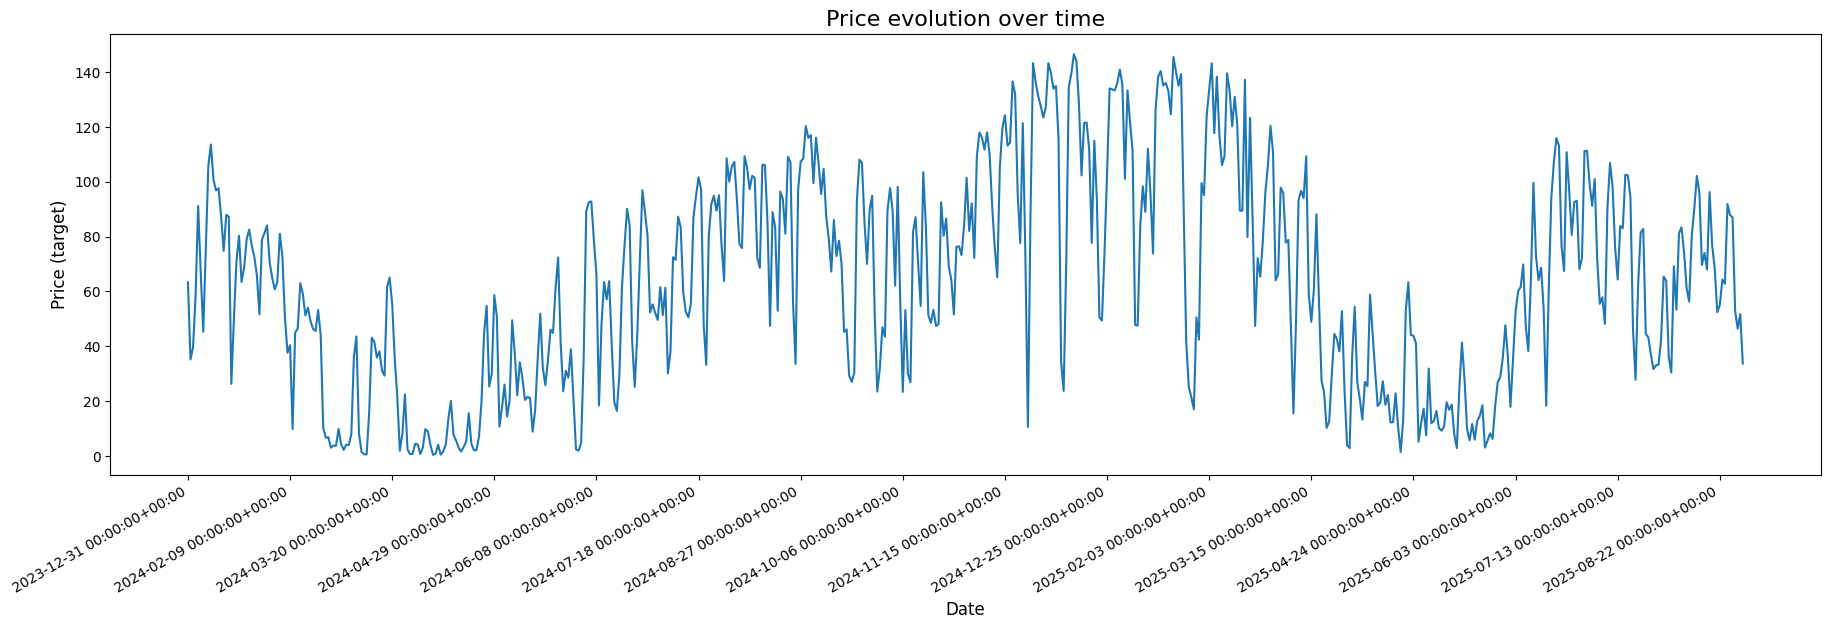

In [138]:
plt.figure(figsize=(18, 6))

sns.lineplot(
    data=df,
    x= df['datetime'],
    y='target')

plt.title("Price evolution over time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (target)", fontsize=12)

plt.xticks(df['datetime'][::40], rotation=45)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

Lo que queremos no es un análisis estacional; queremos predecir el precio basándonos en la combinación energética. Por lo tanto, ya no utilizaremos la columna «datetime» y la eliminaremos.

In [139]:
# We discard the datetime column.
df = df.drop(columns=['datetime'])

# We save the dataframe 
df.to_csv('./data/processed/data.csv')

<div id='id3' />

## 3. Train y Test
Hemos dividido los datos al azar en dos conjuntos: entrenamiento y prueba.


In [140]:
# We separate into train and test
train_set, test_set = train_test_split(df, test_size = 0.2, random_state=42)
train_set.to_csv('./data/train/train_set.csv')
test_set.to_csv('./data/test/test_set.csv')

<div id='id4' />

## 4. Análisis Univariante:
Analicemos las variables incluidas en los datos.


### 4.1 Objetivo: Precio diario del mercado SPOT (€/MWh)
El mercado diario es un mercado mayorista en el que las transacciones de electricidad para el día siguiente se establecen mediante la presentación de ofertas de compra y venta de electricidad por parte de los participantes en el mercado.
Como resultado, se determinan simultáneamente el precio diario del mercado en cada zona de suministro, los programas de toma y entrega de energía, y los programas de intercambio entre zonas de suministro.

(2,)


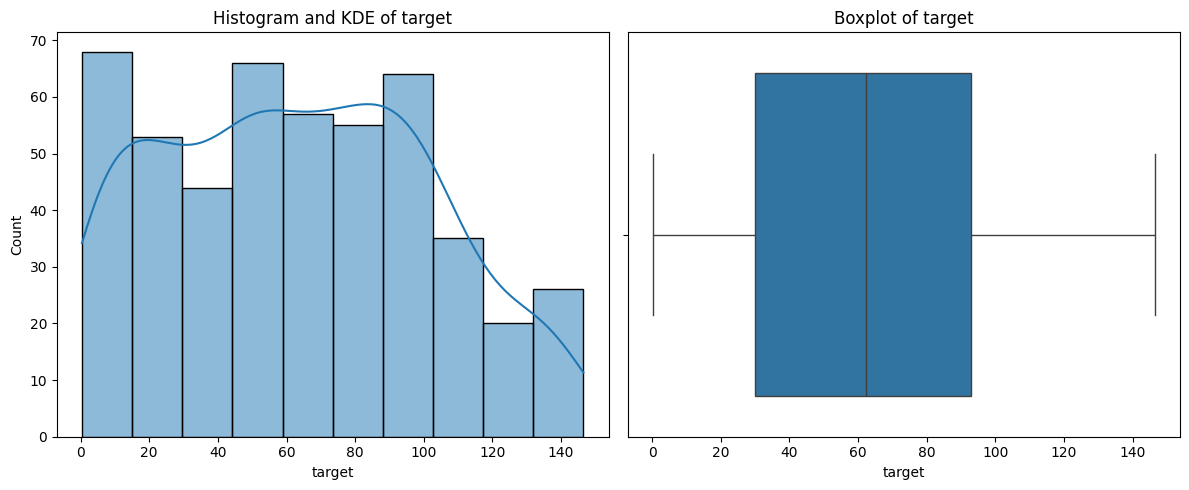

In [141]:
# Let's see how the target is distributed.
ev.plot_combined_graphs(train_set, ['target'])

In [142]:
train_set['target'].describe()

count    488.000000
mean      63.058748
std       38.718154
min        0.401250
25%       29.858437
50%       62.434583
75%       92.837812
max      146.515000
Name: target, dtype: float64

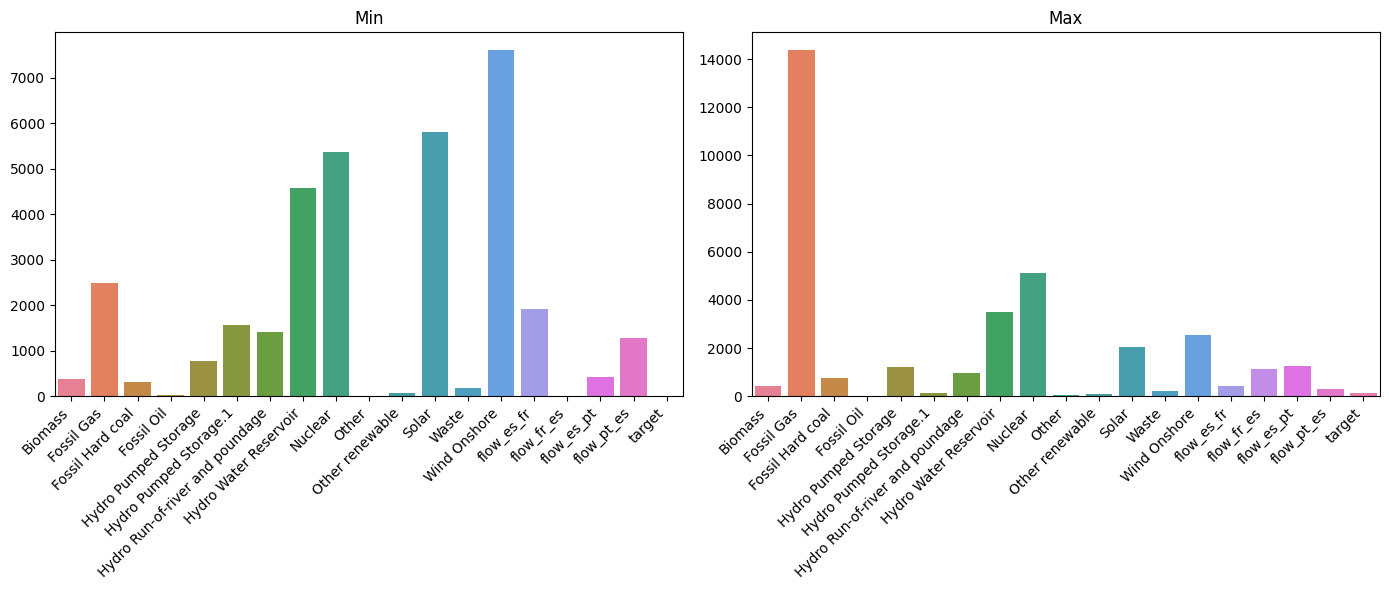

In [143]:
fig, (ax1, ax2) = plt.subplots( nrows=1, ncols=2, figsize=(14, 6) )
sns.barplot(train_set.loc[train_set['target'] == train_set['target'].min()], ax=ax1)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_title('Min')
sns.barplot(train_set.loc[train_set['target'] == train_set['target'].max()], ax=ax2)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title('Max')
plt.tight_layout()
plt.show()

(2,)


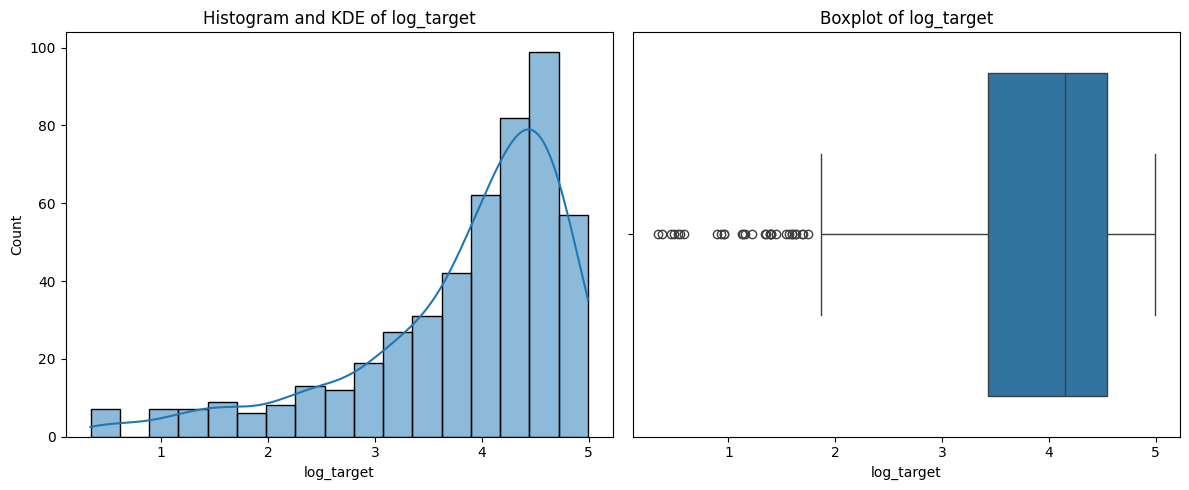

In [144]:
# Let's see how the target is distributed with logarithmic transformation.
train_set_copy = train_set.copy()
train_set_copy['log_target'] = np.log1p(train_set['target'])
ev.plot_combined_graphs(train_set_copy, ['log_target'])

### 4.2 Otras variables


(18, 2)


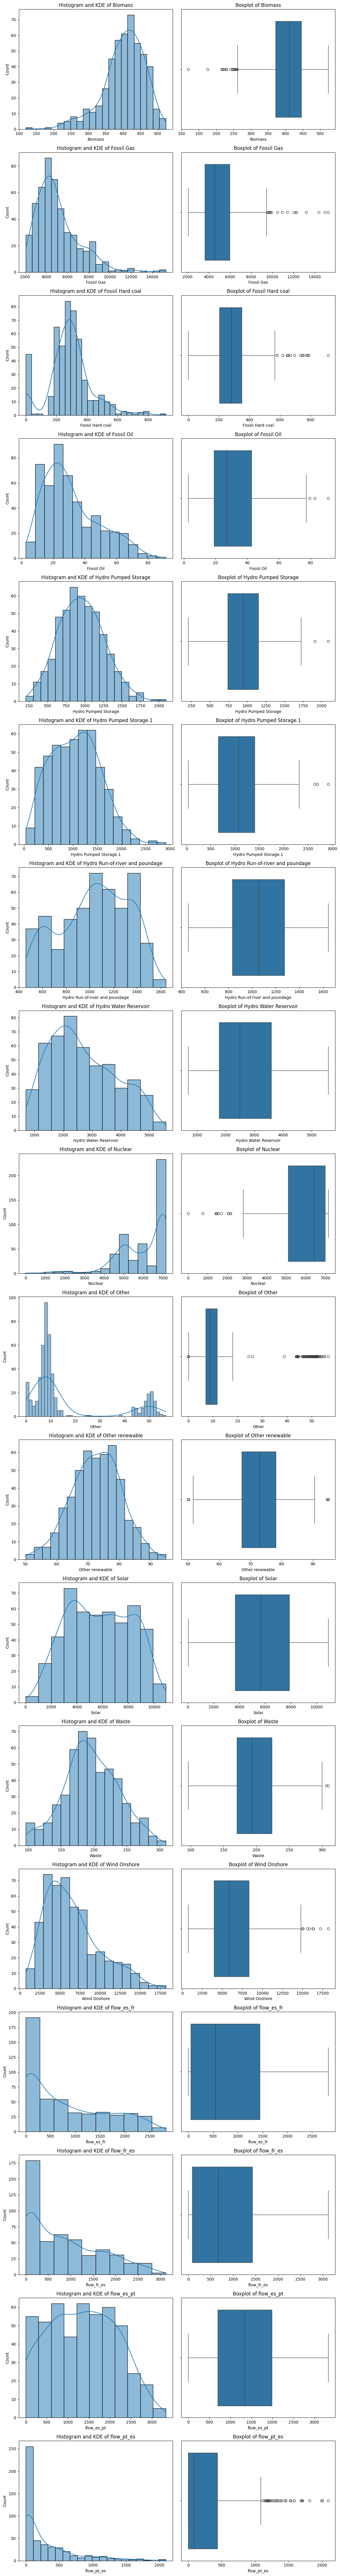

In [145]:
# Graphs for the remaining variables
ev.plot_combined_graphs(train_set, [col for col in train_set.columns if col != 'target'])

Todas las variables son numéricas continuas.

<div id='id5' />

# 5. Análisis Bivariate
Vamos a crear una matriz de correlación para ver qué variables tienen mayor influencia sobre la variable objetivo.

<Axes: >

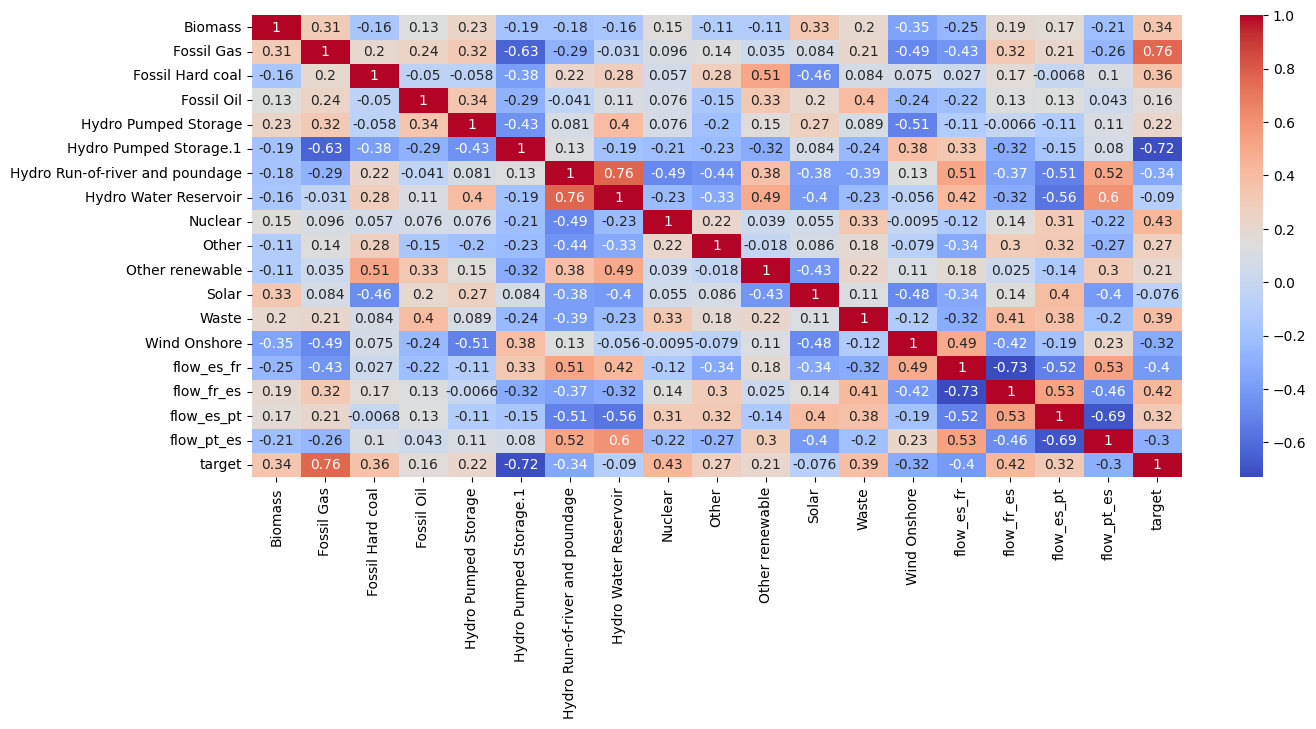

In [146]:
# Correlation matrix
plt.figure(figsize=(15,6))
sns.heatmap(train_set.corr(), annot=True, cmap='coolwarm')

In [147]:
# Variables sorted by correlation
train_set.corr()['target'].sort_values(ascending=False).round(2)

target                             1.00
Fossil Gas                         0.76
Nuclear                            0.43
flow_fr_es                         0.42
Waste                              0.39
Fossil Hard coal                   0.36
Biomass                            0.34
flow_es_pt                         0.32
Other                              0.27
Hydro Pumped Storage               0.22
Other renewable                    0.21
Fossil Oil                         0.16
Solar                             -0.08
Hydro Water Reservoir             -0.09
flow_pt_es                        -0.30
Wind Onshore                      -0.32
Hydro Run-of-river and poundage   -0.34
flow_es_fr                        -0.40
Hydro Pumped Storage.1            -0.72
Name: target, dtype: float64

Tenemos variables que influyen en el precio al hacerlo subir:
- Gas fósil
- Embalse hidroeléctrico
- Almacenamiento por bombeo hidroeléctrico

Otras que influyen en el precio al hacerlo bajar:
- Almacenamiento por bombeo hidroeléctrico.1
- Eólica terrestre 

La conclusión que podemos extraer de esto es que **cuando se utilizan energías no renovables, el precio sube**.

Convirtamos las cifras en valores absolutos para ver el orden de influencia, independientemente de si es positiva o negativa:

In [148]:
# Variables sorted by correlation abs value
train_set.corr()['target'].abs().sort_values(ascending=False)

target                             1.000000
Fossil Gas                         0.757207
Hydro Pumped Storage.1             0.718690
Nuclear                            0.430731
flow_fr_es                         0.416822
flow_es_fr                         0.401364
Waste                              0.387311
Fossil Hard coal                   0.362867
Biomass                            0.338039
Hydro Run-of-river and poundage    0.337556
flow_es_pt                         0.323861
Wind Onshore                       0.319511
flow_pt_es                         0.297456
Other                              0.274762
Hydro Pumped Storage               0.215931
Other renewable                    0.208536
Fossil Oil                         0.158406
Hydro Water Reservoir              0.089661
Solar                              0.075577
Name: target, dtype: float64

<div id='id6' />

## 6. Tratamiento de los valores atípicos
En el gráfico de caja y barbas de la variable objetivo, podemos observar que hay valores atípicos a la derecha. Para mejorar nuestro modelo, vamos a descartar los valores atípicos, ya que no queremos aprender de ellos. 
No queremos aprender de días concretos en los que el precio fue inusualmente alto debido a determinadas circunstancias; queremos que funcione en el día a día.  
Eliminaremos aquellos que superen el doble de la distancia intercuartílica a la derecha.

In [149]:
Q1 = train_set['target'].quantile(0.25)
Q3 = train_set['target'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3+2*IQR

# How many outliers are there?
print( "Number of outliers:", len(train_set[(train_set['target'] >= upper)]) )
train_set[(train_set['target'] >= upper)]

Number of outliers: 0


,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Pumped Storage.1,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore,flow_es_fr,flow_fr_es,flow_es_pt,flow_pt_es,target
